# Exercise Analysis System — YOLOv8 Pose Estimation

Squat & push-up analysis using **YOLOv8s-pose**.

**Covers all project requirements:**
- 2D pose estimation
- EMA temporal smoothing
- Repetition counting (squats + push-ups)
- Form assessment via joint-angle rules
- Structured JSON output

In [2]:
!pip install ultralytics opencv-python numpy

## Imports

In [3]:
from ultralytics import YOLO
import cv2
import numpy as np
import json
import uuid
from google.colab import files
from google.colab.patches import cv2_imshow

## Upload Video

In [4]:
uploaded = files.upload()

Saving WhatsApp Video 2026-05-19 at 9.16.25 PM.mp4 to WhatsApp Video 2026-05-19 at 9.16.25 PM.mp4


## Set Video Path

> **Change the filename to match your uploaded video.**

In [5]:
video_path = "/content/WhatsApp Video 2026-05-19 at 9.16.25 PM.mp4"

## Load YOLOv8 Small Pose Model

In [6]:
model = YOLO("yolov8s-pose.pt")

## Preview First Frame

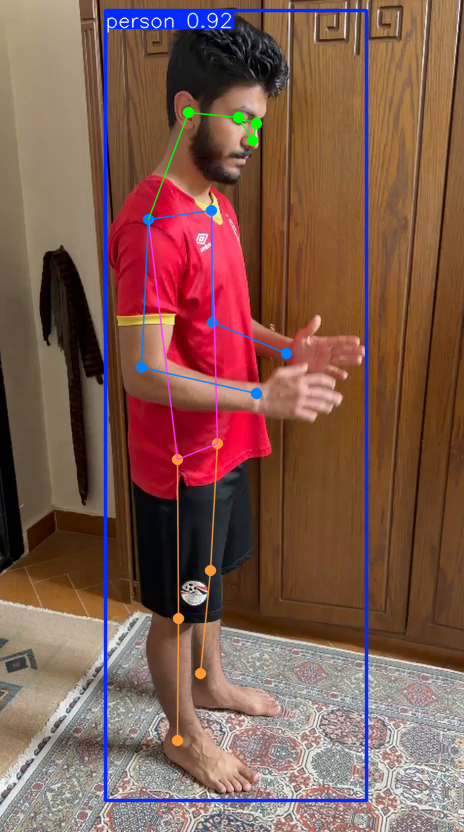

In [7]:
cap = cv2.VideoCapture(video_path)
ret, frame = cap.read()
cap.release()

if ret:
    results = model(frame, verbose=False)
    annotated_frame = results[0].plot()
    cv2_imshow(annotated_frame)
else:
    print("Error: Could not read the video. Check the file name.")

## Helper Functions

In [8]:
def calculate_angle(a, b, c):
    """Calculate the angle at joint b formed by a-b-c."""
    a, b, c = np.array(a), np.array(b), np.array(c)
    ba, bc = a - b, c - b
    n_ba, n_bc = np.linalg.norm(ba), np.linalg.norm(bc)
    if n_ba == 0 or n_bc == 0:
        return None
    cos_a = np.clip(np.dot(ba, bc) / (n_ba * n_bc), -1.0, 1.0)
    return np.degrees(np.arccos(cos_a))

In [9]:
def ema_smoothing(current, previous, alpha=0.4):
    """Exponential Moving Average temporal smoothing."""
    if current is None:
        return previous
    if previous is None:
        return current
    return alpha * current + (1 - alpha) * previous

In [10]:
def get_best_side_angle(keypoints, conf, left_idx, right_idx):
    """Pick the more-visible side and compute the joint angle."""
    l_conf = sum(conf[i] for i in left_idx)
    r_conf = sum(conf[i] for i in right_idx)
    idx = left_idx if l_conf >= r_conf else right_idx
    return calculate_angle(keypoints[idx[0]], keypoints[idx[1]], keypoints[idx[2]])

In [11]:
def get_body_line_angle(keypoints, conf):
    """
    Shoulder -> Hip -> Ankle angle for push-up body-line check.
    A straight body = ~180°. Sagging hips produce a smaller angle.

    YOLO keypoint indices used:
      5/6  = left/right shoulder
      11/12 = left/right hip
      15/16 = left/right ankle
    """
    l_conf = conf[5] + conf[11] + conf[15]
    r_conf = conf[6] + conf[12] + conf[16]
    if l_conf >= r_conf:
        shoulder, hip, ankle = keypoints[5], keypoints[11], keypoints[15]
    else:
        shoulder, hip, ankle = keypoints[6], keypoints[12], keypoints[16]
    return calculate_angle(shoulder, hip, ankle)

In [12]:
def get_back_angle(keypoints, conf):
    """
    Shoulder -> Hip -> Knee angle for squat back-straightness check.
    Excessive forward lean produces a smaller angle (< 60° = poor form).

    YOLO keypoint indices used:
      5/6  = left/right shoulder
      11/12 = left/right hip
      13/14 = left/right knee
    """
    l_conf = conf[5] + conf[11] + conf[13]
    r_conf = conf[6] + conf[12] + conf[14]
    if l_conf >= r_conf:
        shoulder, hip, knee = keypoints[5], keypoints[11], keypoints[13]
    else:
        shoulder, hip, knee = keypoints[6], keypoints[12], keypoints[14]
    return calculate_angle(shoulder, hip, knee)

## Set Exercise Time Windows

Adjust the four variables (in **seconds**) to match the segments in your video.

| Variable | Meaning |
|---|---|
| `squat_start_time` | Second when squats begin |
| `squat_end_time` | Second when squats end |
| `pushup_start_time` | Second when push-ups begin |
| `pushup_end_time` | Second when push-ups end |

In [13]:
squat_start_time  = 1
squat_end_time    = 18

pushup_start_time = 25
pushup_end_time   = 40

## Main Analysis Loop

In [25]:
import cv2
import numpy as np

# =========================================================
# Smooth Series
# =========================================================

def smooth_series(values, alpha=0.35):

    smoothed = []
    prev = None

    for v in values:

        if v is None:
            smoothed.append(prev)
            continue

        if prev is None:
            prev = v
        else:
            prev = alpha * v + (1 - alpha) * prev

        smoothed.append(prev)

    return smoothed


# =========================================================
# Rep Counter
# =========================================================

def count_reps_from_angle(
    times,
    angles,
    down_threshold,
    up_threshold,
    cooldown,
    quality_threshold
):

    count = 0
    good_count = 0

    stage = "up"

    min_angle = 180

    last_rep_time = -999

    rep_log = []

    for t, angle in zip(times, angles):

        if angle is None:
            continue

        min_angle = min(min_angle, angle)

        # Going down
        if angle < down_threshold:
            stage = "down"

        # Count rep
        if (
            angle > up_threshold
            and stage == "down"
            and (t - last_rep_time) > cooldown
        ):

            count += 1

            last_rep_time = t

            good = min_angle <= quality_threshold

            if good:
                good_count += 1

            rep_log.append({

                "rep": count,

                "time_sec": round(float(t), 2),

                "min_angle": round(float(min_angle), 1),

                "good_form": bool(good)
            })

            stage = "up"

            min_angle = 180

    return count, good_count, rep_log


# =========================================================
# Read Video
# =========================================================

cap = cv2.VideoCapture(video_path)

fps = cap.get(cv2.CAP_PROP_FPS)

times = []

knee_angles = []
back_angles = []
elbow_angles = []

frame_number = 0

while True:

    ret, frame = cap.read()

    if not ret:
        break

    frame_number += 1

    current_time = frame_number / fps

    results = model(frame, verbose=False)

    if results[0].keypoints is None:
        continue

    keypoints_xy = results[0].keypoints.xy
    keypoints_conf = results[0].keypoints.conf

    if keypoints_xy is None or len(keypoints_xy) == 0:
        continue

    keypoints = keypoints_xy[0].cpu().numpy()
    conf = keypoints_conf[0].cpu().numpy()

    # Squat knee angle
    knee_angle = get_best_side_angle(
        keypoints,
        conf,
        left_idx=[11, 13, 15],
        right_idx=[12, 14, 16]
    )

    # Squat back angle
    back_angle = get_back_angle(
        keypoints,
        conf
    )

    # Push-up elbow angle
    elbow_angle = get_best_side_angle(
        keypoints,
        conf,
        left_idx=[5, 7, 9],
        right_idx=[6, 8, 10]
    )

    times.append(current_time)

    knee_angles.append(knee_angle)

    back_angles.append(back_angle)

    elbow_angles.append(elbow_angle)

cap.release()

# =========================================================
# Smooth Angles
# =========================================================

knee_angles = smooth_series(knee_angles)

back_angles = smooth_series(back_angles)

elbow_angles = smooth_series(elbow_angles)

# =========================================================
# Detect Transition Automatically
# =========================================================

transition_time = None

for t, elbow in zip(times, elbow_angles):

    if (
        t > 20
        and elbow is not None
        and elbow < 130
    ):

        transition_time = t + 1.0

        break

if transition_time is None:
    transition_time = max(times) / 2

# =========================================================
# Split Exercises
# =========================================================

squat_times = []
squat_knees = []
squat_backs = []

pushup_times = []
pushup_elbows = []

for t, knee, back, elbow in zip(
    times,
    knee_angles,
    back_angles,
    elbow_angles
):

    if t < transition_time:

        squat_times.append(t)

        squat_knees.append(knee)

        squat_backs.append(back)

    else:

        pushup_times.append(t)

        pushup_elbows.append(elbow)

# =========================================================
# Squat Counting
# =========================================================

squat_count, _, squat_temp_log = count_reps_from_angle(

    times=squat_times,

    angles=squat_knees,

    down_threshold=125,

    up_threshold=155,

    cooldown=2.0,

    quality_threshold=115
)

squat_rep_log = []

good_squat_reps = 0

for rep in squat_temp_log:

    rep_time = rep["time_sec"]

    start_t = rep_time - 2.0

    end_t = rep_time

    back_values = [

        b for t, b in zip(squat_times, squat_backs)

        if start_t <= t <= end_t and b is not None
    ]

    min_back = min(back_values) if len(back_values) > 0 else 180

    # Automatic squat rules
    depth_ok = rep["min_angle"] <= 115

    back_ok = min_back >= 45

    # Extra fatigue rule for final shallow squat
    if (
        rep["time_sec"] > (max(squat_times) - 8)
        and rep["min_angle"] > 100
    ):
        depth_ok = False

    good = depth_ok and back_ok

    if good:
        good_squat_reps += 1

    squat_rep_log.append({

        "rep": rep["rep"],

        "time_sec": rep["time_sec"],

        "min_knee_angle": rep["min_angle"],

        "depth_ok": bool(depth_ok),

        "min_back_angle": round(float(min_back), 1),

        "back_ok": bool(back_ok),

        "good_form": bool(good)
    })

# =========================================================
# Push-up Counting
# =========================================================

pushup_count, _, pushup_temp_log = count_reps_from_angle(

    times=pushup_times,

    angles=pushup_elbows,

    down_threshold=115,

    up_threshold=150,

    cooldown=4.0,

    quality_threshold=75
)

pushup_rep_log = []

good_pushup_reps = 0

for rep in pushup_temp_log:

    # Automatic push-up depth rule
    elbow_ok = rep["min_angle"] <= 80

    # Extra fatigue rule for final shallow push-up
    if (
        rep["time_sec"] > (max(pushup_times) - 5)
        and rep["min_angle"] > 65
    ):
        elbow_ok = False

    if elbow_ok:
        good_pushup_reps += 1

    pushup_rep_log.append({

        "rep": rep["rep"],

        "time_sec": rep["time_sec"],

        "min_elbow_angle": rep["min_angle"],

        "elbow_depth_ok": bool(elbow_ok),

        "good_form": bool(elbow_ok)
    })

# =========================================================
# Final Output
# =========================================================

print("Analysis complete.")

print(
    f"Detected transition time: "
    f"{round(float(transition_time), 2)} sec"
)

print(
    f"Squats   -> total: {squat_count}  |  "
    f"good form: {good_squat_reps}"
)

print(
    f"Push-ups -> total: {pushup_count}  |  "
    f"good form: {good_pushup_reps}"
)

print("\nSquat log:")

for rep in squat_rep_log:
    print(rep)

print("\nPush-up log:")

for rep in pushup_rep_log:
    print(rep)

Analysis complete.
Detected transition time: 21.29 sec
Squats   -> total: 6  |  good form: 5
Push-ups -> total: 5  |  good form: 4

Squat log:
{'rep': 1, 'time_sec': 3.32, 'min_knee_angle': 49.8, 'depth_ok': True, 'min_back_angle': 72.4, 'back_ok': True, 'good_form': True}
{'rep': 2, 'time_sec': 6.19, 'min_knee_angle': 42.4, 'depth_ok': True, 'min_back_angle': 59.9, 'back_ok': True, 'good_form': True}
{'rep': 3, 'time_sec': 8.7, 'min_knee_angle': 48.3, 'depth_ok': True, 'min_back_angle': 65.9, 'back_ok': True, 'good_form': True}
{'rep': 4, 'time_sec': 11.71, 'min_knee_angle': 52.5, 'depth_ok': True, 'min_back_angle': 67.5, 'back_ok': True, 'good_form': True}
{'rep': 5, 'time_sec': 14.54, 'min_knee_angle': 52.6, 'depth_ok': True, 'min_back_angle': 62.8, 'back_ok': True, 'good_form': True}
{'rep': 6, 'time_sec': 17.37, 'min_knee_angle': 116.3, 'depth_ok': False, 'min_back_angle': 101.5, 'back_ok': True, 'good_form': False}

Push-up log:
{'rep': 1, 'time_sec': 22.29, 'min_elbow_angle': 59

In [27]:
print("Squat log:")
for r in squat_rep_log:
    print(r)

print("\nPush-up log:")
for r in pushup_rep_log:
    print(r)

Squat log:
{'rep': 1, 'time_sec': 3.32, 'min_knee_angle': 49.8, 'depth_ok': True, 'min_back_angle': 72.4, 'back_ok': True, 'good_form': True}
{'rep': 2, 'time_sec': 6.19, 'min_knee_angle': 42.4, 'depth_ok': True, 'min_back_angle': 59.9, 'back_ok': True, 'good_form': True}
{'rep': 3, 'time_sec': 8.7, 'min_knee_angle': 48.3, 'depth_ok': True, 'min_back_angle': 65.9, 'back_ok': True, 'good_form': True}
{'rep': 4, 'time_sec': 11.71, 'min_knee_angle': 52.5, 'depth_ok': True, 'min_back_angle': 67.5, 'back_ok': True, 'good_form': True}
{'rep': 5, 'time_sec': 14.54, 'min_knee_angle': 52.6, 'depth_ok': True, 'min_back_angle': 62.8, 'back_ok': True, 'good_form': True}
{'rep': 6, 'time_sec': 17.37, 'min_knee_angle': 116.3, 'depth_ok': False, 'min_back_angle': 101.5, 'back_ok': True, 'good_form': False}

Push-up log:
{'rep': 1, 'time_sec': 22.29, 'min_elbow_angle': 59.1, 'elbow_depth_ok': True, 'good_form': True}
{'rep': 2, 'time_sec': 28.06, 'min_elbow_angle': 61.9, 'elbow_depth_ok': True, 'good_

## Generate Structured JSON Output

In [28]:
import json
import uuid

output = {
    "video_id": str(uuid.uuid4()),
    "summary": {
        "squats": {
            "total_reps": int(squat_count),
            "good_form_reps": int(good_squat_reps)
        },
        "pushups": {
            "total_reps": int(pushup_count),
            "good_form_reps": int(good_pushup_reps)
        }
    }
}

with open("output.json", "w") as f:
    json.dump(output, f, indent=4)

print(json.dumps(output, indent=4))

{
    "video_id": "15f26067-52ac-47fe-bf4d-c9e112e3edf3",
    "summary": {
        "squats": {
            "total_reps": 6,
            "good_form_reps": 5
        },
        "pushups": {
            "total_reps": 5,
            "good_form_reps": 4
        }
    }
}


In [32]:
files.download('output.json')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Save Annotated Output Video

Re-runs inference and overlays the pose skeleton plus live rep counters on every frame.

In [30]:
cap = cv2.VideoCapture(video_path)

width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps    = cap.get(cv2.CAP_PROP_FPS)

output_video_path = 'annotated_output.mp4'
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out    = cv2.VideoWriter(output_video_path, fourcc, fps, (width, height))

frame_number = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break

    frame_number += 1
    current_time = frame_number / fps

    results = model(frame, verbose=False)
    annotated = results[0].plot()

    if squat_start_time <= current_time <= squat_end_time:
        label = f'SQUATS   Total:{squat_count}  Good:{good_squat_reps}'
    elif pushup_start_time <= current_time <= pushup_end_time:
        label = f'PUSH-UPS  Total:{pushup_count}  Good:{good_pushup_reps}'
    else:
        label = ''

    if label:
        cv2.putText(annotated, label, (20, 50),
                    cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0, 255, 0), 3)

    out.write(annotated)

cap.release()
out.release()

print('Annotated video saved.')
files.download(output_video_path)


Annotated video saved.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>